In [1]:
import matplotlib.pyplot as plt
import gymnasium as gym
import numpy as np
import torch
import src.metropolis_hastings as mh
import time

from src.time_varying_vine_copula import tv_vinecop, obs_transform_pend2, action_transform_pendulum, SlidingWindowDataset
from src.copula import conditional_vine_copula
from rl_code.modelnp import pendulum
from rl_code.lspi import LSPI

from src.qbvine import qb_conditional_vine, splitdiscrete_qb_conditional_vines

In [14]:
n_episodes, sim_len, n_eval, n_stop_modelupdate = 10, 1000, 100, 25
true_param = np.array([9.8, 2.0, 8.0, 0.5,10.0, 0.1])
true_pendulum = pendulum(true_param)
my_lspi = LSPI(true_pendulum, sim_len, None)
old_policy = my_lspi.random_policy

st = time.time()

### calculate episodic return
all_returns, disc_returns = [], []
init_state = np.random.uniform(low=-1e-10, high=1e-10, size=2)
all_s = np.empty((0, 2))
#all_s2 = np.empty((0, 2))
all_a = np.empty((0,1))
episode_ends = np.zeros(n_eval, dtype = int)
end_idx = 0
for i in range(n_eval):
    eval_s, eval_a, eval_s2, eval_r = true_pendulum.simulate_episode(first_state=init_state, policy=old_policy)
    print(eval_r.T)
    eval_s_corrected = np.concatenate((eval_s, [eval_s2[-1]]))
    eval_a_corrected = np.concatenate((eval_a, [[0]]))
    all_s = np.concatenate((all_s, eval_s_corrected))
    #all_s2 = np.concatenate((all_s2, eval_s2))
    all_a = np.concatenate((all_a, eval_a_corrected))
    discounts = np.array(my_lspi.gamma**np.arange(len(eval_r)))
    discounted_return = discounts.T @ np.array(eval_r)
    all_returns.append(np.sum(eval_r)), disc_returns.append(discounted_return[0])
    end_idx += len(eval_a_corrected)
    episode_ends[i] = end_idx-1
episode_ends = episode_ends[:-1]
print(f"Episode 1 return: {np.mean(all_returns)}")
print(episode_ends)
print(len(all_a))
print(len(all_a)-len(episode_ends))



[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 0.]]
[[1. 1. 1. 1. 1. 1. 1

In [ ]:
# n_episodes, sim_len, n_eval, n_stop_modelupdate = 10, 1000, 5, 25
# true_param = np.array([9.8, 2.0, 8.0, 0.5,10.0, 0.1])
# true_pendulum = pendulum(true_param)
# my_lspi = LSPI(true_pendulum, sim_len, None)
# old_policy = my_lspi.random_policy
# n_acts = 0
# while n_acts <30:
#     eval_s, eval_a, eval_s2, eval_r = true_pendulum.simulate_episode(first_state=init_state, policy=old_policy)
#     end_idx += len(eval_r)
#     n_acts = len(eval_a)
# print(eval_r.T)

# all_s = eval_s
# all_a = eval_a
# all_s2 = eval_s2

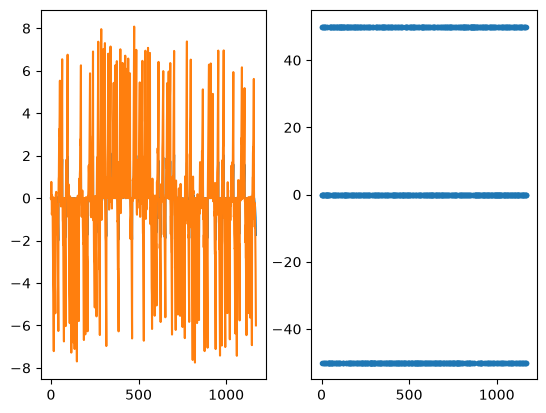

In [15]:
fig, ax = plt.subplots(1,2)
ax[0].plot(all_s)
ax[1].plot(all_a, '.')


In [21]:
class pendulum_vines:
    def __init__(self, rbp_train_max = 500, discrete_action = True):
        self.rbp_train_max = rbp_train_max
        self.discrete = discrete_action
        self.obs_transformer = obs_transform_pend2(standardise=True)

    def fit(self, observations, actions, episode_ends = None):
        if self.discrete:
            # Fit transformer 
            self.obs_transformer.fit(torch.from_numpy(observations))
            trans_obs = self.obs_transformer.transform(torch.from_numpy(observations)).numpy()
            trans_data = np.concatenate((trans_obs, actions), axis=1)

            self.qbcondcop = splitdiscrete_qb_conditional_vines(observation_d=3, discrete_action=1, action_set=np.unique(actions))
            self.qbcondcop.fit(trans_data, check_vines=True, episode_ends=episode_ends)

    def predict_next_state(self, observation, action, transformed = False, num_samples = 50):
        if transformed:
            self.qbcondcop.step_forward(np.expand_dims(observation, axis=0), action)
        else:
            trans_obs = self.obs_transformer.transform(observation).numpy()
            self.qbcondcop.step_forward(trans_obs, action)

        preds = self.qbcondcop.sample_next_state(n_samples=num_samples)
        predicted_next = self.obs_transformer.inv_transform_mean(torch.from_numpy(preds))

        return predicted_next


    def simulate_trajectory(self, policy=None, horizon=50):
        action_space = torch.tensor([-50.0, 0.0, 50.0])
        n_action = action_space.shape[0]
    
        rand_unif_dist1 = torch.distributions.uniform.Uniform(-1e-5, 1e-5)
        s_history = rand_unif_dist1.sample(torch.Size([horizon,2]))
        s_dash_history = torch.zeros(horizon, 2)
        a_history = torch.zeros(horizon, 1)
        r_history = torch.zeros(horizon, 1)
    
        for time in range(horizon):
            ## random policy
            idx = torch.randint(0, n_action, (1,))
            action_now = action_space[idx].item()

            a_history[time] = action_now
    
            #training_x = torch.hstack([s_history[time], torch.tensor([action_now], dtype=torch.float32)]).view(1, -1)
            next_state = self.predict_next_state(torch.unsqueeze(s_history[time],dim=0), action_now, transformed=False)
            s_dash_history[time, :] = torch.squeeze(next_state)
    
            if torch.abs(next_state[0][0]) <= torch.pi / 2:
                next_reward = 1.0
                if time < horizon - 1:
                    s_history[time + 1, :] = s_dash_history[time, :]
            else:
                next_reward = 0.0
                
            r_history[time] = torch.tensor(next_reward, dtype=torch.float32)
    
        return s_history, a_history, s_dash_history, r_history


In [22]:
test_vine = pendulum_vines()
test_vine.fit(all_s, all_a)

[4 5 6] [1 2 3] [1 2 3 5 6 7]
Cauchy Locs = [np.float64(0.0371047748942034), np.float64(-0.37980334563562396), np.float64(0.015776187855399776)]
Scales = [np.float64(0.22786519142806994), np.float64(0.5247352337838455), np.float64(0.47122849142409434)]
c after hstack (1171, 4)
tstemp (371, 8)
[1 2 3 5 6 7]
<pyvinecopulib.core.Vinecop> Vinecop model with 6 variables
tree edge conditioned variables conditioning variables var_types  family rotation       parameters  df   tau 
   1    1                  2, 5                             c, c    Tawn        0 0.76, 0.95, 7.00 3.0  0.65 
   1    2                  3, 6                             c, c    Tawn      180 0.75, 1.00, 5.63 3.0  0.64 
   1    3                  1, 4                             c, c   Frank        0            22.42 1.0  0.83 
   1    4                  5, 4                             c, c    Tawn      180 0.30, 0.99, 4.60 3.0  0.27 
   1    5                  4, 6                             c, c Student        0 

In [27]:
states, _, _, _ = test_vine.simulate_trajectory()


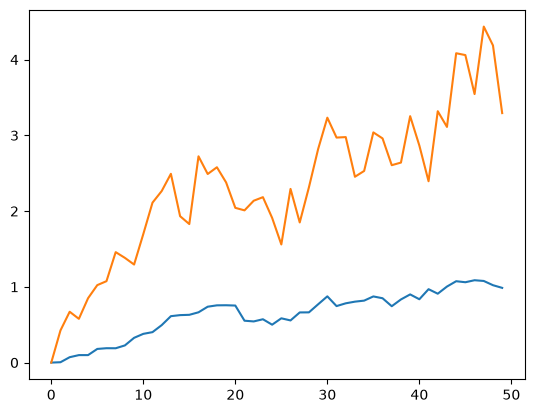

In [28]:
plt.plot(states)

In [ ]:
for i, act in enumerate(all_a[0:episode_ends[0]]):
    print(i)
    got = False
    error_count = 0
    preds = test_vine.predict_next_state()

    #predicted_next[i+1] = np.mean(preds, axis = 0)

    predicted_next[i+1] = obs_transformer.inv_transform_mean(torch.from_numpy(preds))

In [ ]:
fig, ax = plt.subplots(1,2)
x = np.arange(len(predicted_next))
#Plot the 
for i in range(2):
    ax[i].plot(x[:episode_ends[0]], all_s2[:episode_ends[0],i], label = "Observed")
    ax[i].plot(x[:episode_ends[0]], predicted_next[:episode_ends[0],i], label = "Prediction")
    # ax[0, i].fill_between(
    #     x,
    #     predicted_up_err[:, i],
    #     predicted_down_err[:, i],
    #     color = "orange",
    #     alpha=0.25,
    #     label="Prediction uncertainty"
    # )
    #ax[1, i].plot(observations[:,i], predicted_next[:,i] - observations[:,i], '.')

#print(observations[-11], observations[-10], np.mean(chain, axis=0), observations[-9])
plt.savefig("C:/Users/woodg/Documents/Vine_dissertation_chaeyun/plots_rl/roll_out_discrete")
plt.close()

### Appendix

In [ ]:
# data = np.concatenate((all_s, all_a), axis=1)

# obs_transformer = obs_transform_pend2(standardise=True)
# obs_transformer.fit(torch.from_numpy(all_s))
# trans_obs = obs_transformer.transform(torch.from_numpy(all_s)).numpy()

# trans_data = np.concatenate((trans_obs, all_a), axis=1)

# plt.plot(trans_obs)
# plt.show()

# print("Starting Fit")
# # tv = tv_vinecop(observation_d=3, action_d=1, discrete_action=1, action_set=np.unique(all_a))
# # tv.fit(trans_data, check_vines=True, episode_ends = None)
# condcop = splitdiscrete_qb_conditional_vines(observation_d=3, discrete_action=1, action_set=np.unique(all_a))
# condcop.fit(trans_data, check_vines=True, episode_ends=episode_ends)

# print("Fit finished")

# condcop.check_rbp_pdfs_real_line(x_max=20)

# plt.show()

In [ ]:
# condcop.step_forward(np.array([trans_obs[0]]), all_a[0][0])
# print(condcop.sample_next_state(), trans_obs[1])

In [ ]:
predicted_next = np.zeros_like(all_s)
num_samples = 10
predicted_next[0] = all_s[0]

In [ ]:
#condcop.step_forward(np.array([all_s[0]]), all_a[0][0])
for i, act in enumerate(all_a[0:episode_ends[0]]):
    print(i)
    got = False
    error_count = 0
    while not got:
        try:
            preds = condcop.sample_next_state(n_samples=num_samples)
            got = True
        except Exception as e:

            error_count +=1
            if error_count>5:
                break
            got = False
            print(f"step {i}, attempt {error_count}: {type(e).__name__}: {e}")

    #predicted_next[i+1] = np.mean(preds, axis = 0)

    predicted_next[i+1] = obs_transformer.inv_transform_mean(torch.from_numpy(preds))

    print(i, act[0])
    pred = obs_transformer.transform(torch.from_numpy(np.expand_dims(predicted_next[i+1], axis = 0)))
    print(pred)
    print(trans_obs[i+1])
    # print(predicted_next[i+1])
    # print(all_s[i+1])
    condcop.step_forward(pred, all_a[i+1][0])
    #condcop.step_forward(np.array([trans_obs[i+1]]), all_a[i+1][0])

## Appendix

In [ ]:
print(trans_obs[0])

tv.step_forward(np.array([trans_obs[0]]), all_a[0][0])
print(tv.last_state.shape)
print(np.array([trans_obs[0]]))



tv.check_rbp_pdfs_real_line(x_max=30)
#tv.check_conditional_vine_pdfs()
tv.check_rbp_times_conditional_vine()
plt.show()

In [ ]:
tv.step_forward(np.array([trans_obs[0]]), all_a[0][0])


for i, act in enumerate(all_a[0:9]):
    pred, pred_std, ar, fig = tv.predict_next_state(action = act[0], covariance=0.01, chain_length=600, 
                                                    burn_in = 300, check_chain=True, check_acceptance = False)
    plt.show()
    plt.close()
    print(pred)
    predicted_next[i+1] = obs_transformer.inverse_transform(torch.from_numpy(np.expand_dims(pred, axis=0)))
    predicted_up_err[i+1] = obs_transformer.inverse_transform(torch.from_numpy(np.expand_dims(pred+pred_std, axis=0)))
    predicted_down_err[i+1] = obs_transformer.inverse_transform(torch.from_numpy(np.expand_dims(pred-pred_std, axis=0)))
    print(i, act[0], ar)

    tv.step_forward(np.array([pred]), all_a[i+1][0])

In [ ]:
print(predicted_next)
fig, ax = plt.subplots(2,2)
x = np.arange(len(predicted_next))
#Plot the 
for i in range(2):
    ax[0, i].plot(x, all_s2[:,i], label = "Observed")
    ax[0, i].plot(x, predicted_next[:,i], label = "Prediction")
    ax[0, i].fill_between(
        x,
        predicted_up_err[:, i],
        predicted_down_err[:, i],
        color = "orange",
        alpha=0.25,
        label="Prediction uncertainty"
    )
    #ax[1, i].plot(observations[:,i], predicted_next[:,i] - observations[:,i], '.')

#print(observations[-11], observations[-10], np.mean(chain, axis=0), observations[-9])
plt.savefig("C:/Users/woodg/Documents/Vine_dissertation_chaeyun/plots_rl/roll_out_discrete")
plt.close()